
# Publisher & Developer Ecosystem Analysis
Using **indie.csv** and **notindie.csv**

This notebook analyzes the **developer** and **publisher** ecosystems across indie vs non‑indie games:
- Top developers and publishers
- Indie‑only vs Non‑indie‑only publishers
- Developers/Publishers per game distributions
- Self‑published rates


In [12]:

import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", 200)

def parse_list(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else (x if isinstance(x, list) else [])
    except Exception:
        return []

def merge_publishers(row):
    pubs = []
    for col in ["publishers_steam", "publishers_epic"]:
        if col in row and isinstance(row[col], list):
            pubs.extend([p for p in row[col] if isinstance(p, str)])
    return pubs

def df_to_md_table(df, title):
    # Build markdown header
    md = f"### {title}\n\n"
    md += "| " + " | ".join(df.columns) + " |\n"
    md += "| " + " | ".join(["---"] * len(df.columns)) + " |\n"
    
    # Add rows
    for _, row in df.iterrows():
        md += "| " + " | ".join(str(x) for x in row.values) + " |\n"
    
    display(Markdown(md))


## Load & Parse Data

In [3]:
indie_path = '../data/gold/indie.csv'
notindie_path = '../data/gold/notindie.csv'
indie = pd.read_csv(indie_path)
notindie = pd.read_csv(notindie_path)

for df in [indie, notindie]:
    df["developers"] = df["developers"].apply(parse_list)
    df["publishers_steam"] = df["publishers_steam"].apply(parse_list)
    df["publishers_epic"] = df["publishers_epic"].apply(parse_list)
    df["all_publishers"] = df.apply(merge_publishers, axis=1)

print("Indie shape:", indie.shape, "| Not‑indie shape:", notindie.shape)
indie.head(3)


Indie shape: (91916, 21) | Not‑indie shape: (59293, 21)


,Unnamed: 0,id,steam_ID,epic_ID,igdb_ID,title,platform,developers,publishers_steam,publishers_epic,...,categories_epic,categories_igdb,effective_date_steam,effective_date_epic,effective_date_igdb,price_steam,price_epic,discount_percent_steam,discount_percent_epic,all_publishers
0,1,2,2556940.0,NaN,NaN,! shakabula *,['steam'],[Skermunkel],[Skermunkel],[],...,[],[],2023-10-13,NaN,NaN,13.88,NaN,0.0,NaN,[Skermunkel]
1,2,3,449940.0,NaN,NaN,! that bastard is trying to steal our gold !,['steam'],[WTFOMGames],[WTFOMGames],[],...,[],[],2016-03-03,NaN,NaN,2.77,NaN,0.0,NaN,[WTFOMGames]
2,4,5,866510.0,NaN,NaN,!anyway!,['steam'],[EYEFRONT],[EYEFRONT],[],...,[],[],2018-06-06,NaN,NaN,1.84,NaN,0.0,NaN,[EYEFRONT]


## Flatten Developer/Publisher Lists

In [4]:

indie_devs = [d for row in indie["developers"] for d in row]
not_devs   = [d for row in notindie["developers"] for d in row]

indie_pubs = [p for row in indie["all_publishers"] for p in row]
not_pubs   = [p for row in notindie["all_publishers"] for p in row]

len(indie_devs), len(not_devs), len(indie_pubs), len(not_pubs)


(54978, 21546, 52492, 20377)

## Frequency Counts

In [ ]:

indie_dev_counts = Counter(indie_devs)
not_dev_counts   = Counter(not_devs)

indie_pub_counts = Counter(indie_pubs)
not_pub_counts   = Counter(not_pubs)

top20_indie_devs = pd.DataFrame(indie_dev_counts.most_common(20), columns=["Developer","Count"])
top20_not_devs   = pd.DataFrame(not_dev_counts.most_common(20), columns=["Developer","Count"])

top20_indie_pubs = pd.DataFrame(indie_pub_counts.most_common(20), columns=["Publisher","Count"])
top20_not_pubs   = pd.DataFrame(not_pub_counts.most_common(20), columns=["Publisher","Count"])



df_to_md_table(top20_indie_devs, "Top 20 Indie Developers")
df_to_md_table(top20_not_devs, "Top 20 Non-Indie Developers")
df_to_md_table(top20_indie_pubs, "Top 20 Indie Publishers")
df_to_md_table(top20_not_pubs, "Top 20 Non-Indie Publishers")


### Top 20 Indie Developers

| Developer | Count |
| --- | --- |
| Choice of Games | 137 |
| Boogygames Studios | 107 |
| Laush Dmitriy Sergeevich | 105 |
| Hosted Games | 94 |
| Sokpop Collective | 84 |
| Tero Lunkka | 79 |
| Follow the fun | 65 |
| EpiXR Games UG | 63 |
| Blender Games | 60 |
| Valkeala Software | 59 |
| Dnovel | 59 |
| Blessing Company | 52 |
| RewindApp | 52 |
| Hede | 52 |
| Gamesforgames | 48 |
| Samet Acar | 46 |
| Kairosoft Co.,Ltd | 44 |
| SAT-BOX | 43 |
| Anamik Majumdar | 42 |
| Nikita "Ghost_RUS" | 41 |


### Top 20 Non-Indie Developers

| Developer | Count |
| --- | --- |
| Creobit | 110 |
| KOEI TECMO GAMES CO., LTD. | 105 |
| Square Enix | 73 |
| Elephant Games | 73 |
| Somer Games | 63 |
| MAGIX Software GmbH | 58 |
| Do Games Limited | 53 |
| Eipix Entertainment | 49 |
| William at Oxford | 46 |
| AMAX Interactive | 46 |
| Gamesforgames | 45 |
| G-MODE | 43 |
| Archor Wright | 43 |
| CyberStep, Inc. | 40 |
| magnussoft | 40 |
| MAGES. Inc. | 40 |
| HexWar Games | 37 |
| CAPCOM Co., Ltd. | 37 |
| Milestone S.r.l. | 37 |
| CyberLink | 36 |


### Top 20 Indie Publishers

| Publisher | Count |
| --- | --- |
| Choice of Games | 137 |
| Conglomerate 5 | 128 |
| Laush Studio | 118 |
| Kagura Games | 114 |
| Boogygames Studios | 107 |
| PlayWay S.A. | 102 |
| My Way Games | 100 |
| SA Industry | 97 |
| Plug In Digital | 95 |
| Hosted Games | 94 |
| PLAYISM | 93 |
| HH-Games | 87 |
| Sokpop Collective | 84 |
| Sekai Project | 81 |
| Piece Of Voxel | 80 |
| Devolver Digital | 78 |
| tinyBuild | 77 |
| Alawar Casual | 75 |
| Tero Lunkka | 72 |
| GrabTheGames | 67 |


### Top 20 Non-Indie Publishers

| Publisher | Count |
| --- | --- |
| Big Fish Games | 427 |
| 8floor | 229 |
| KOEI TECMO GAMES CO., LTD. | 96 |
| Ziggurat | 92 |
| Square Enix | 92 |
| Nacon | 82 |
| Electronic Arts | 77 |
| Pixel Games UK | 73 |
| SEGA | 70 |
| THQ Nordic | 65 |
| HH-Games | 64 |
| Microids | 62 |
| Shiravune | 61 |
| Atari | 59 |
| MAGIX Software GmbH | 59 |
| Artifex Mundi | 58 |
| Ubisoft | 58 |
| KOMODO | 57 |
| Strategy First | 55 |
| Sekai Project | 53 |


## Top 20 Developers — Indie vs Non‑Indie (Bar Charts)

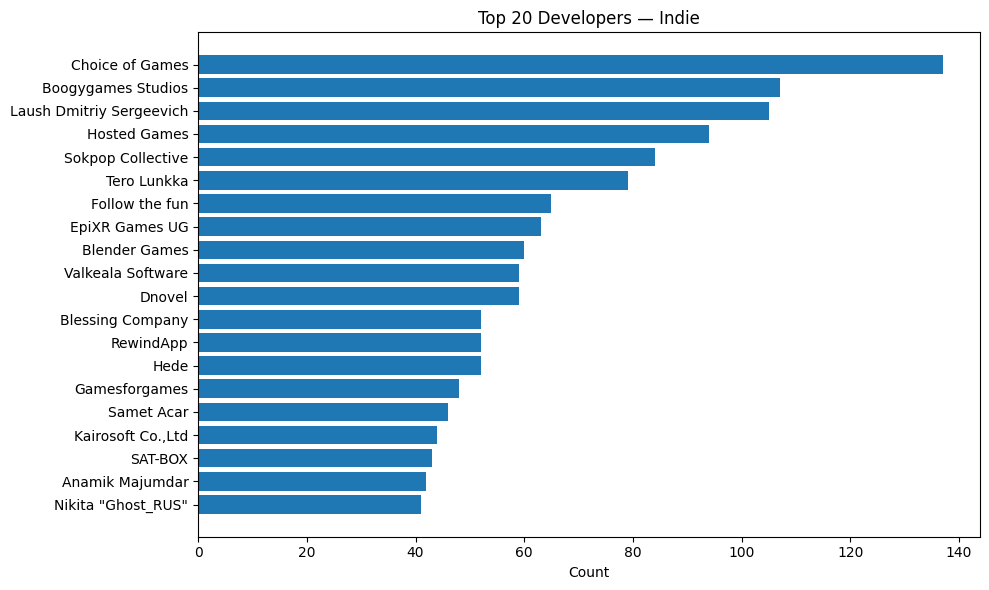

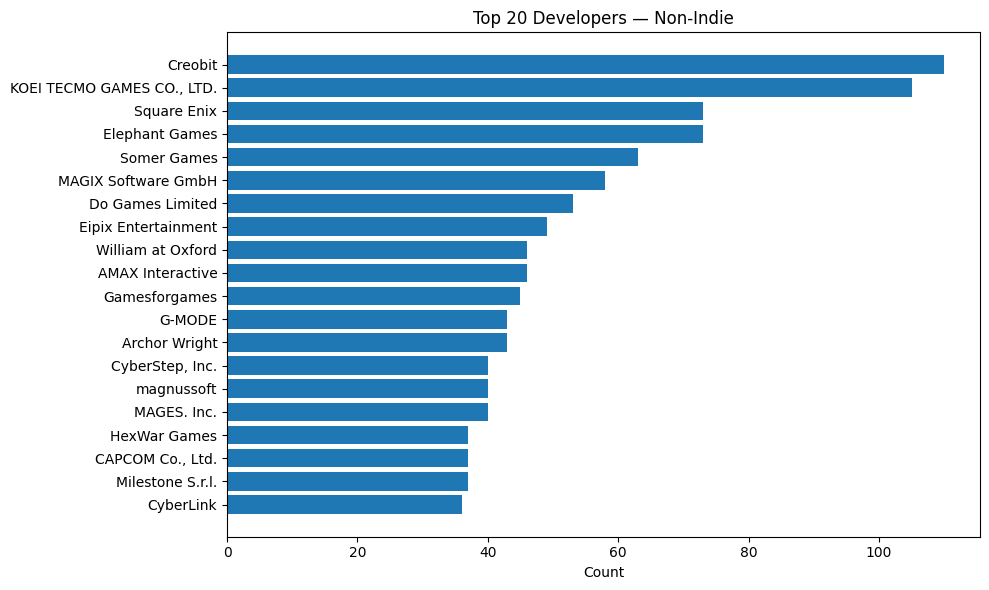

In [9]:

plt.figure(figsize=(10,6))
plt.barh(top20_indie_devs["Developer"][::-1], top20_indie_devs["Count"][::-1])
plt.xlabel("Count")
plt.title("Top 20 Developers — Indie")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.barh(top20_not_devs["Developer"][::-1], top20_not_devs["Count"][::-1])
plt.xlabel("Count")
plt.title("Top 20 Developers — Non‑Indie")
plt.tight_layout()
plt.show()


## Top 20 Publishers — Indie vs Non‑Indie (Bar Charts)

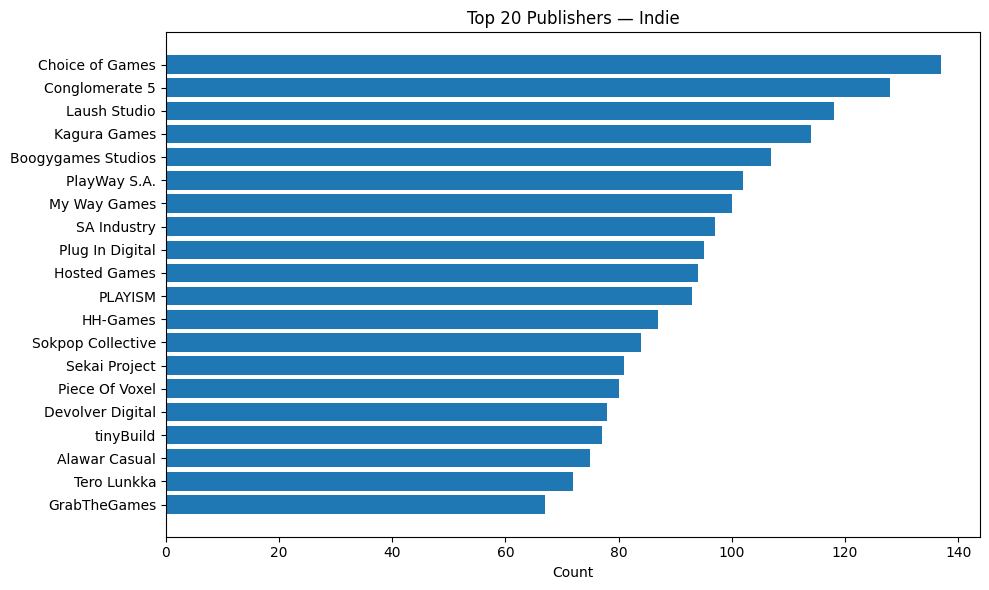

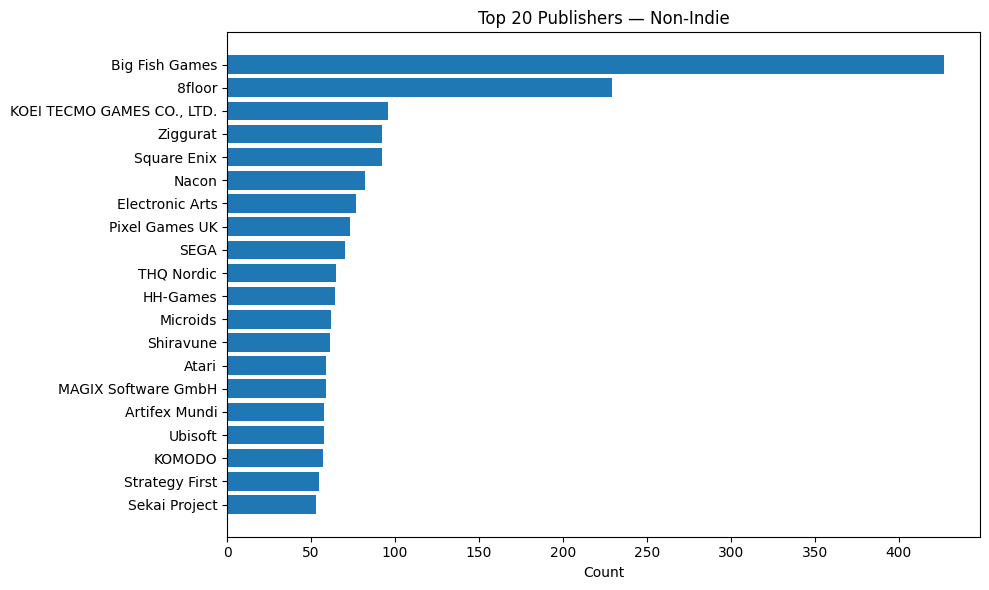

In [10]:

plt.figure(figsize=(10,6))
plt.barh(top20_indie_pubs["Publisher"][::-1], top20_indie_pubs["Count"][::-1])
plt.xlabel("Count")
plt.title("Top 20 Publishers — Indie")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.barh(top20_not_pubs["Publisher"][::-1], top20_not_pubs["Count"][::-1])
plt.xlabel("Count")
plt.title("Top 20 Publishers — Non‑Indie")
plt.tight_layout()
plt.show()


## Indie‑Only vs Non‑Indie‑Only Publishers

In [14]:

indie_only_pubs = {p: indie_pub_counts[p] for p in indie_pub_counts if p not in not_pub_counts}
not_only_pubs   = {p: not_pub_counts[p] for p in not_pub_counts if p not in indie_pub_counts}

top10_indie_only_pubs = pd.DataFrame(
    sorted(indie_only_pubs.items(), key=lambda x: -x[1])[:10],
    columns=["Publisher", "Count"]
)
top10_not_only_pubs = pd.DataFrame(
    sorted(not_only_pubs.items(), key=lambda x: -x[1])[:10],
    columns=["Publisher", "Count"]
)

df_to_md_table(top10_indie_only_pubs, "TOP 10 indie only publishers")
df_to_md_table(top10_not_only_pubs, "TOP 10 non-indie only publishers")


### TOP 10 indie only publishers

| Publisher | Count |
| --- | --- |
| Boogygames Studios | 107 |
| Hosted Games | 94 |
| Blender Games | 60 |
| I commissioned some series | 60 |
| RewindApp | 52 |
| PsychoFlux Entertainment | 51 |
| Ghost_RUS Games | 48 |
| Sometimes You | 45 |
| Anamik Majumdar | 42 |
| Inspector Studios | 37 |


### TOP 10 non-indie only publishers

| Publisher | Count |
| --- | --- |
| KOEI TECMO GAMES CO., LTD. | 96 |
| Ziggurat | 92 |
| Shiravune | 61 |
| MAGIX Software GmbH | 59 |
| Do Games Limited | 53 |
| Outright Games Ltd. | 50 |
| Spike Chunsoft Co., Ltd. | 49 |
| Disney | 46 |
| HIKARI FIELD | 44 |
| magnussoft | 40 |


### Visuals: Indie‑Only / Non‑Indie‑Only Publishers

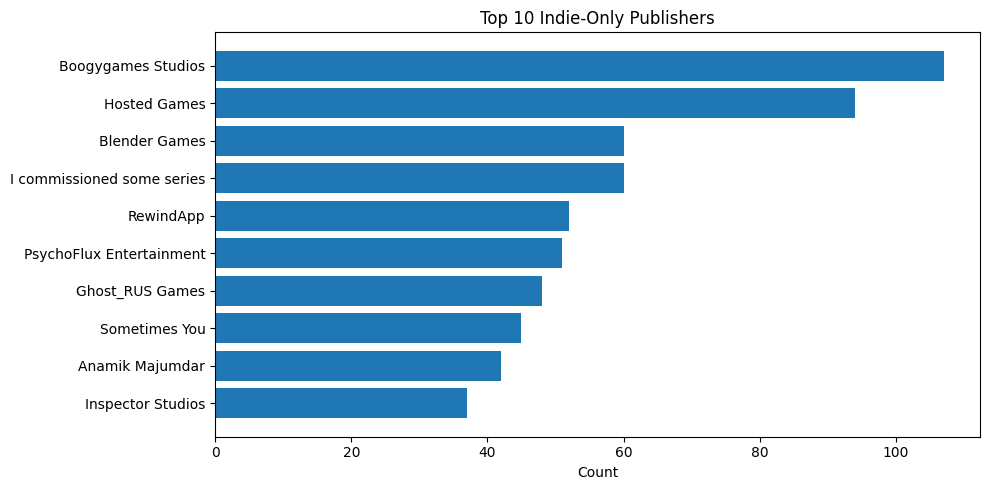

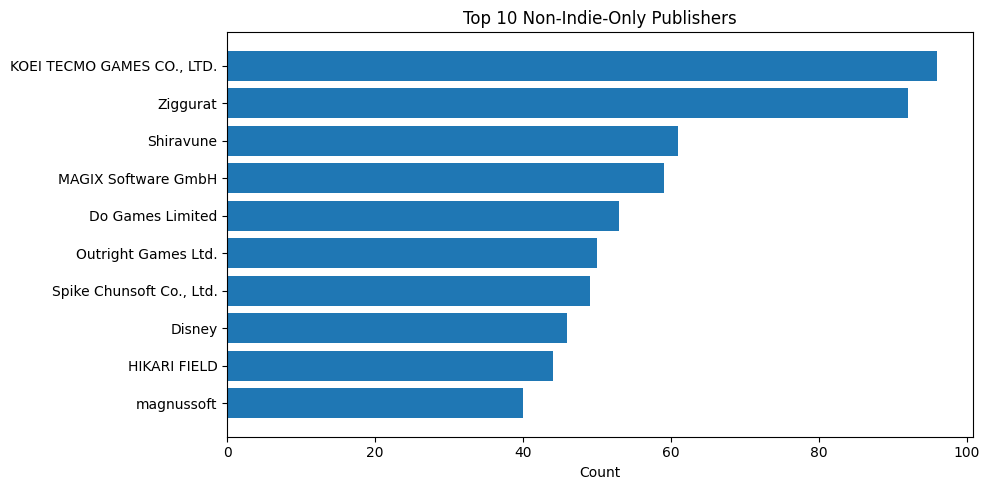

In [15]:

plt.figure(figsize=(10,5))
plt.barh(top10_indie_only_pubs["Publisher"][::-1], top10_indie_only_pubs["Count"][::-1])
plt.xlabel("Count")
plt.title("Top 10 Indie‑Only Publishers")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.barh(top10_not_only_pubs["Publisher"][::-1], top10_not_only_pubs["Count"][::-1])
plt.xlabel("Count")
plt.title("Top 10 Non‑Indie‑Only Publishers")
plt.tight_layout()
plt.show()


## Ecosystem Statistics

In [16]:

stats = {
    "Indie: Avg Developers per Game": indie["developers"].apply(len).mean(),
    "Non‑Indie: Avg Developers per Game": notindie["developers"].apply(len).mean(),
    "Indie: Avg Publishers per Game": indie["all_publishers"].apply(len).mean(),
    "Non‑Indie: Avg Publishers per Game": notindie["all_publishers"].apply(len).mean(),
    "Indie: % Self‑Published (0 publishers)": (indie["all_publishers"].apply(len) == 0).mean(),
    "Non‑Indie: % Self‑Published (0 publishers)": (notindie["all_publishers"].apply(len) == 0).mean(),
}
pd.Series(stats).round(3)


Indie: Avg Developers per Game                0.598
Non‑Indie: Avg Developers per Game            0.363
Indie: Avg Publishers per Game                0.571
Non‑Indie: Avg Publishers per Game            0.344
Indie: % Self‑Published (0 publishers)        0.449
Non‑Indie: % Self‑Published (0 publishers)    0.672
dtype: float64